# TADKit - Interactive Anomaly Detection demonstrator

Dropdown(description='Select:', options=('synchronous', 'asynchronous'), value='synchronous')

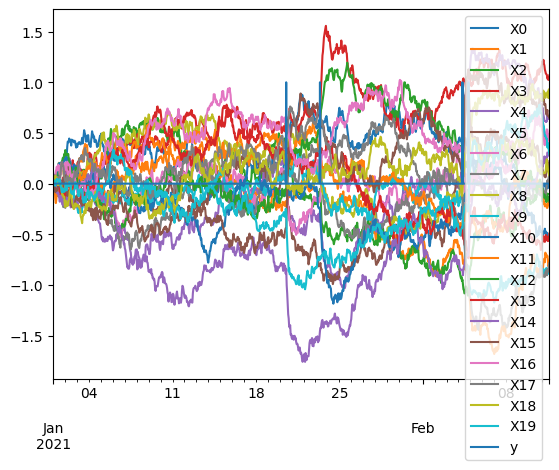

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ouagen import ornstein_uhlenbeck_anomaly


t = np.arange(1000)
t = t / t.shape[0]
pre_X, pre_y = ornstein_uhlenbeck_anomaly(
    t,
    size=20,
    noise_scale=1,
    mean_reverting=3,
    anomaly_freq=.1,
    anomaly_duration=0.005,
    anomaly_scale=40,
)
t = pd.to_datetime('2021-01-01') + pd.Timedelta(1, 'h') * np.arange(t.shape[0])
X = pd.DataFrame(pre_X, index=t, columns=[f'X{i}' for i in range(pre_X.shape[1])])
y = pd.DataFrame(pre_y[:, None], index=t, columns=['y'])
async_X = X.melt(value_vars=X.columns.tolist(), ignore_index=False).rename(
    columns={"variable": "sensor", "value": "data"}
)
pd.concat([X, y], axis=1).plot()

import ipywidgets as widgets

# Create a dropdown selection widget
select = widgets.Dropdown(
    options=["synchronous", "asynchronous"],
    value="synchronous",
    description='Select:'
)
display(select)

In [2]:
from tadkit.catalog.rawtowideformatter import RawToWideFormatter

target_X = X if select.value == "synchronous" else async_X
formatter = RawToWideFormatter(
    data=target_X,
    backend="pandas"
)
print(f"Formatter has {formatter.available_properties=}")

Formatter has formatter.available_properties=['synchronous', 'pandas_backend', 'fixed_time_step']


<font color="orange"> This allows to select a training interval, a resampling resolution and the set of target sensors for learning. </font>

In [ ]:
from query_selection import query_widget_selection

query_dict = query_widget_selection(formatter.query_description)

In [4]:
query_translated = {key: widget.value for key, widget in query_dict.items()}
X_train = formatter.format(**query_translated)
query_translated.pop("target_period")
X_test = formatter.format(**query_translated)

ax = X_test.plot()
ax.axvspan(X_train.index[0], X_train.index[-1], alpha=0.2)
plt.show()

UFuncTypeError: ufunc 'greater_equal' did not contain a loop with signature matching types (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

In [ ]:
from tadkit.base.registry import registry
import tadkit.catalog.registry_init  # ensure registrations happen

registry.print_catalog_classes()
registry.list_learners()
registry.match_learners(formatter)

[registry] Skipping optional learner 'DataReconstructionAD': No module named 'cnndrad'
[registry] Skipping optional learner 'KcpLearner': No module named 'kcpdi'
[registry] Skipping optional learner 'DiLAnoDetectm': No module named 'sbad_fnn'
[TADkit registered Catalog]
Class learner_name='IsolationForest' is registered in TADKit.
IsolationForest is operational in this environment.
IsolationForest somewhat somehow doesn't implicitly inherit from TADLearner.
Class learner_name='KDEOutlierDetector' is registered in TADKit.
KDEOutlierDetector is operational in this environment.
KDEOutlierDetector somewhat somehow doesn't implicitly inherit from TADLearner.
Class learner_name='GMMOutlierDetector' is registered in TADKit.
GMMOutlierDetector is operational in this environment.
GMMOutlierDetector somewhat somehow doesn't implicitly inherit from TADLearner.
Class learner_name='TopologicalAnomalyDetector' is registered in TADKit.
TopologicalAnomalyDetector is operational in this environment.
To

[sklearn.ensemble._iforest.IsolationForest,
 tadkit.catalog.sklearners.KDEOutlierDetector,
 tadkit.catalog.sklearners.GMMOutlierDetector,
 tdaad.anomaly_detectors.TopologicalAnomalyDetector]

In [ ]:
for learner_cls in registry.match_learners(formatter):
    learner = learner_cls()  # instantiate directly
    print(f"Instantiated {learner_cls.__name__}")

Instantiated IsolationForest
Instantiated KDEOutlierDetector
Instantiated GMMOutlierDetector
Instantiated TopologicalAnomalyDetector


In [ ]:
from tadkit.utils.param_spec import params_from_class
from tadkit.utils.render_widgets_from_params import render_widgets_from_params

learner_params = {}
for learner_class in registry.match_learners(formatter):
    learner_params.setdefault(learner_class.__name__, {})
    print(learner_class.__name__)
    params_specs = params_from_class(learner_class)
    widgets, learner_params[learner_class.__name__] = render_widgets_from_params(params_specs)

IsolationForest


KDEOutlierDetector


GMMOutlierDetector


TopologicalAnomalyDetector


In [ ]:
from sklearn.ensemble import IsolationForest
params_from_class(IsolationForest)["n_estimators"]

{'default': 100,
 'description': 'The number of base estimators in the ensemble.',
 'type': int,
 'bounds': {'min': 1, 'max': None, 'closed': 'left'},
 'options': None,
 'allow_none': False,
 'widget': 'slider',
 'widget_args': {'min': 1, 'max': None, 'step': 1, 'default': 100}}

In [ ]:
learner_params["GMMOutlierDetector"]()

{'covariance_type': 'full',
 'means_init': None,
 'verbose': 0,
 'contamination': 0.1,
 'precisions_init': None,
 'n_init': 1,
 'verbose_interval': 10,
 'tol': 0.001,
 'random_state': None,
 'n_components': 1,
 'warm_start': False,
 'reg_covar': 1e-06,
 'max_iter': 100,
 'weights_init': None,
 'init_params': 'kmeans'}

In [ ]:
learner_params["TopologicalAnomalyDetector"]()
learners = {
    learner_class.__name__:
    learner_class(**learner_params[learner_class.__name__]())
    for learner_class in registry.match_learners(formatter)
}
learners

{'IsolationForest': IsolationForest(),
 'KDEOutlierDetector': KDEOutlierDetector(),
 'GMMOutlierDetector': GMMOutlierDetector(),
 'TopologicalAnomalyDetector': TopologicalAnomalyDetector()}

<font color="orange"> Fit on train query, score on the entire series. </font>

Fitting IsolationForest
Fitting KDEOutlierDetector
Fitting GMMOutlierDetector
Fitting TopologicalAnomalyDetector
Scoring with IsolationForest
Scoring with KDEOutlierDetector
Scoring with GMMOutlierDetector
Scoring with TopologicalAnomalyDetector


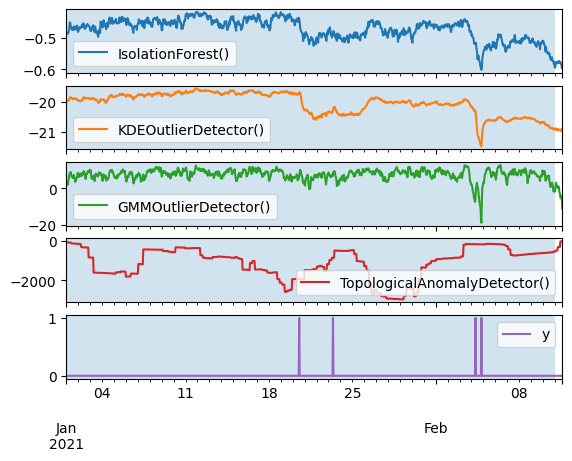

In [ ]:
# Fit loop:
anomalies = pd.DataFrame(index=X_test.index)
for learner_name, learner_object in learners.items():
    print(f"Fitting {learner_name}")
    learner_object.fit(X_train)

# Score loop:
for learner_name, fitted_learner_object in learners.items():
    print(f"Scoring with {learner_name}")
    anom_score = fitted_learner_object.score_samples(X_test)
    anomalies[str(fitted_learner_object)] = anom_score

axes = pd.concat([anomalies, y], axis=1).plot(subplots=True)
[ax.axvspan(X_train.index[0], X_train.index[-1], alpha=0.2) for ax in axes]
plt.show()

In [ ]:
anomalies["KDEOutlierDetector()"]

2021-01-01 00:00:00   -19.997012
2021-01-01 01:00:00   -19.998136
2021-01-01 02:00:00   -19.980378
2021-01-01 03:00:00   -19.966937
2021-01-01 04:00:00   -19.950183
                         ...    
2021-02-11 11:00:00   -20.947900
2021-02-11 12:00:00   -20.964116
2021-02-11 13:00:00   -20.907034
2021-02-11 14:00:00   -20.949330
2021-02-11 15:00:00   -20.981169
Name: KDEOutlierDetector(), Length: 1000, dtype: float64

In [ ]:
from plotly.offline import init_notebook_mode
from plotly.graph_objs import *
init_notebook_mode(connected=True)         # initiate notebook for offline plot

pd.options.plotting.backend = "plotly"
df = pd.concat([anomalies.apply(lambda x: (x - x.min()) / (x.max() - x.min())), y], axis=1)
import plotly.express as px
fig = df.plot(color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(
    legend=dict(
        orientation="v",
        entrywidth=100,
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    width=1000,
    height=600,
)
fig.show()
pd.options.plotting.backend = "matplotlib"